# Advanced Time-Series Business Simulations

Four additional decision-support simulations, all built on the same STL + block-bootstrap Monte Carlo engine used in `business_simulations.ipynb`, but going a layer deeper into *specific decisions* rather than general risk metrics:

1. **Shock / scenario stress-testing** — inject a deliberate supply shock or policy event into the simulation and measure its downstream impact, rather than only replaying ordinary historical noise.
2. **Buy-now vs. wait-and-see (real options)** — compares a fixed purchase decision against an *adaptive* strategy that reacts to how prices actually unfold, and quantifies the value of that flexibility.
3. **Price-guarantee / insurance pricing** — uses the simulated price distribution to actuarially price a floor-price contract (e.g. a cooperative guaranteeing farmers a minimum price).
4. **Staggered order timing** — compares splitting a purchase across multiple future weeks against buying all at once, and sweeps the number of installments to find the point of diminishing returns.

This notebook is self-contained (re-derives the simulation engine from raw data), so it can be run independently of the earlier notebooks.

## 0. Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
%matplotlib inline
np.random.seed(42)


# ---- Project root: resolved relative to this notebook, independent of the machine/OS it runs on ----
def _find_project_root(marker=os.path.join("data", "raw", "kalimati_tarkari_dataset.csv")):
    path = os.getcwd()
    for _ in range(6):
        if os.path.exists(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            break
        path = parent
    raise FileNotFoundError(
        "Could not locate the project root (expected to find data/raw/kalimati_tarkari_dataset.csv "
        "within a few parent directories of the current working directory).")


PROJECT_ROOT = _find_project_root()

# ---- CONFIG ----
CSV_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "kalimati_tarkari_dataset.csv")
DATE_COL = "Date"
COMMODITY_COL = "Commodity"
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "reports", "from notebooks", "advanced_simulation_outputs")

N_SIMS = 1000
HORIZON_DAYS = 365
BLOCK_SIZE = 14
TREND_LOOKBACK_DAYS = 180

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [14]:
df = pd.read_csv(CSV_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
for col in ["Minimum", "Maximum", "Average"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=[DATE_COL, COMMODITY_COL, "Average"])
df = (df.groupby([COMMODITY_COL, DATE_COL], as_index=False)
        .agg({"Average": "mean"}))
df = df.sort_values([COMMODITY_COL, DATE_COL]).reset_index(drop=True)

print(f"{len(df)} rows, {df[COMMODITY_COL].nunique()} commodities, "
      f"{df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")

197161 rows, 132 commodities, 2013-06-16 to 2021-05-13


## 1. Monte Carlo Simulation Engine (same as `business_simulations.ipynb`)

In [15]:
def fit_stl(df, commodity, period=365):
    g = (df[df[COMMODITY_COL] == commodity]
         .set_index(DATE_COL)["Average"].sort_index().asfreq("D"))
    g = g.interpolate(limit=14).dropna()
    if len(g) < period * 1.5:
        raise ValueError(f"{commodity}: not enough history for a yearly STL fit "
                          f"({len(g)} days, need ~{int(period*1.5)})")
    res = STL(g, period=period, robust=True).fit()
    return g, res


def extrapolate_trend(trend, horizon_days, lookback_days=TREND_LOOKBACK_DAYS):
    recent = trend.iloc[-lookback_days:]
    x = np.arange(len(recent))
    slope, intercept = np.polyfit(x, recent.values, 1)
    last_value = trend.iloc[-1]
    future_x = np.arange(1, horizon_days + 1)
    return last_value + slope * future_x


def extrapolate_seasonal(seasonal, future_dates):
    doy_avg = seasonal.groupby(seasonal.index.dayofyear).mean()
    future_doy = future_dates.dayofyear
    return np.array([doy_avg.get(d, doy_avg.get(365)) for d in future_doy])


def block_bootstrap_residuals(resid, horizon_days, block_size=BLOCK_SIZE, n_sims=N_SIMS):
    resid_vals = resid.values
    n = len(resid_vals)
    n_blocks_needed = int(np.ceil(horizon_days / block_size))
    sims = np.zeros((n_sims, horizon_days))
    for s in range(n_sims):
        blocks = []
        for _ in range(n_blocks_needed):
            start = np.random.randint(0, n - block_size)
            blocks.append(resid_vals[start:start + block_size])
        sims[s] = np.concatenate(blocks)[:horizon_days]
    return sims


def simulate_price_paths(df, commodity, horizon_days=HORIZON_DAYS, n_sims=N_SIMS, block_size=BLOCK_SIZE):
    g, res = fit_stl(df, commodity)
    last_date = g.index[-1]
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon_days, freq="D")

    trend_future = extrapolate_trend(res.trend, horizon_days)
    seasonal_future = extrapolate_seasonal(res.seasonal, future_dates)
    resid_sims = block_bootstrap_residuals(res.resid, horizon_days, block_size, n_sims)

    price_paths = trend_future[None, :] + seasonal_future[None, :] + resid_sims
    price_paths = np.clip(price_paths, a_min=0, a_max=None)

    return pd.DataFrame(price_paths, columns=future_dates), g, res


DEMO_COMMODITY = df[COMMODITY_COL].value_counts().index[0]
baseline_paths, demo_hist, demo_stl = simulate_price_paths(df, DEMO_COMMODITY)
print(f"Demo commodity: {DEMO_COMMODITY}")
print(f"Simulated {baseline_paths.shape[0]} paths x {baseline_paths.shape[1]} days")

Demo commodity: Ginger
Simulated 1000 paths x 365 days


## 2. Shock / Scenario Stress-Testing

**Business question:** *"If a specific bad event happens — a drought cutting supply, a temporary export ban — how does that actually flow through to cost and risk, compared to just ordinary variation?"*

The baseline Monte Carlo simulation only replays *ordinary* historical noise (via the bootstrap). It has no way to represent a deliberate, engineered scenario that hasn't necessarily happened before, or happened rarely. This section lets you inject a specific shock — a temporary or permanent price shift starting at a chosen week — and compares the shocked distribution against the baseline.

In [16]:
def apply_shock(paths, shock_start_day, shock_duration_days, shock_pct, permanent=False):
    """Applies a percentage shift to simulated prices starting at shock_start_day.
    If permanent=False, the shock fades back to baseline linearly over shock_duration_days.
    If permanent=True, the shift persists for the rest of the horizon (e.g. a lasting policy change)."""
    shocked = paths.copy()
    n_days = paths.shape[1]
    multiplier = np.ones(n_days)

    if permanent:
        multiplier[shock_start_day:] = 1 + shock_pct
    else:
        end = min(shock_start_day + shock_duration_days, n_days)
        multiplier[shock_start_day:end] = 1 + shock_pct
        # linear fade back to 1.0 over the following period equal to the shock duration
        fade_end = min(end + shock_duration_days, n_days)
        if fade_end > end:
            multiplier[end:fade_end] = np.linspace(1 + shock_pct, 1, fade_end - end)

    shocked.iloc[:, :] = paths.values * multiplier[None, :]
    return shocked


# Example scenario: a 6-week (~42 day) supply shock starting 4 weeks out, pushing prices up 30%
SHOCK_START_DAY = 28
SHOCK_DURATION_DAYS = 42
SHOCK_PCT = 0.30

shocked_paths = apply_shock(baseline_paths, SHOCK_START_DAY, SHOCK_DURATION_DAYS, SHOCK_PCT, permanent=False)

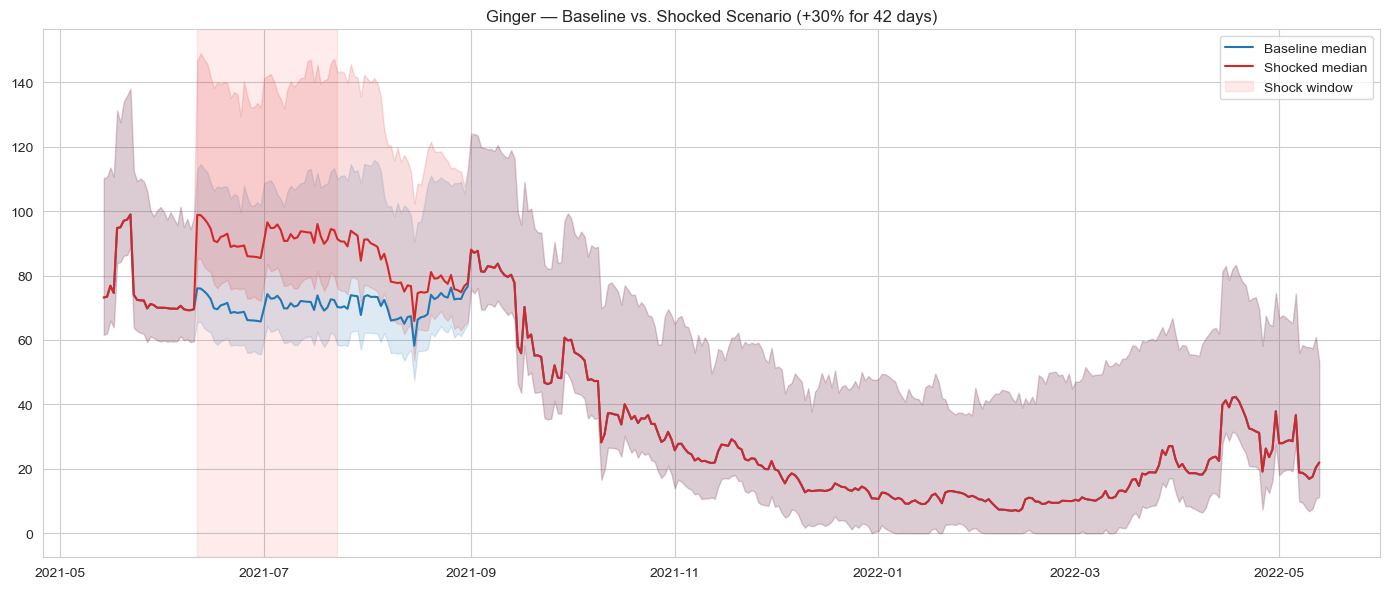

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
future_dates = baseline_paths.columns

for label, paths, color in [("Baseline", baseline_paths, "tab:blue"), ("Shocked", shocked_paths, "tab:red")]:
    median = paths.median(axis=0)
    p10 = paths.quantile(0.10, axis=0)
    p90 = paths.quantile(0.90, axis=0)
    ax.plot(future_dates, median, color=color, label=f"{label} median")
    ax.fill_between(future_dates, p10, p90, alpha=0.15, color=color)

ax.axvspan(future_dates[SHOCK_START_DAY], future_dates[min(SHOCK_START_DAY + SHOCK_DURATION_DAYS, len(future_dates)-1)],
           alpha=0.08, color="red", label="Shock window")
ax.set_title(f"{DEMO_COMMODITY} — Baseline vs. Shocked Scenario (+{SHOCK_PCT:.0%} for {SHOCK_DURATION_DAYS} days)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shock_scenario_{DEMO_COMMODITY.replace(' ', '_')}.png", dpi=150)
plt.show()

In [18]:
# Impact metrics: compare cost of a fixed monthly purchase quantity, baseline vs shocked
QUANTITY = 500   # units purchased over the shock window
shock_cols = future_dates[SHOCK_START_DAY: SHOCK_START_DAY + SHOCK_DURATION_DAYS]

baseline_cost = (baseline_paths[shock_cols].mean(axis=1) * QUANTITY)
shocked_cost = (shocked_paths[shock_cols].mean(axis=1) * QUANTITY)

def var_cvar(costs, confidence=0.95):
    var = np.percentile(costs, confidence * 100)
    cvar = costs[costs >= var].mean()
    return var, cvar

base_var, base_cvar = var_cvar(baseline_cost)
shock_var, shock_cvar = var_cvar(shocked_cost)

print(f"Cost of purchasing {QUANTITY} units across the shock window:")
print(f"  Baseline -- mean: {baseline_cost.mean():.0f}, 95% VaR: {base_var:.0f}, 95% CVaR: {base_cvar:.0f}")
print(f"  Shocked  -- mean: {shocked_cost.mean():.0f}, 95% VaR: {shock_var:.0f}, 95% CVaR: {shock_cvar:.0f}")
print(f"\nExtra expected cost from this scenario: {shocked_cost.mean() - baseline_cost.mean():.0f} "
      f"({(shocked_cost.mean()/baseline_cost.mean() - 1)*100:.1f}% increase)")
print(f"Extra tail-risk exposure (CVaR): {shock_cvar - base_cvar:.0f}")

Cost of purchasing 500 units across the shock window:
  Baseline -- mean: 37677, 95% VaR: 48999, 95% CVaR: 53323
  Shocked  -- mean: 48980, 95% VaR: 63698, 95% CVaR: 69320

Extra expected cost from this scenario: 11303 (30.0% increase)
Extra tail-risk exposure (CVaR): 15997


### Reading this for a business audience

- Adjust `SHOCK_START_DAY`, `SHOCK_DURATION_DAYS`, and `SHOCK_PCT` to model whatever scenario matters to you — a monsoon delay, an import restriction, a fuel-price-driven transport cost spike.
- `permanent=True` models a lasting structural change (e.g. a new tariff) instead of a temporary shock that fades back to baseline — useful for policy-impact analysis.
- The "extra expected cost" and "extra CVaR" numbers are the two most report-ready figures: one for the average-case planning conversation, one for the worst-case reserve-setting conversation.

## 3. Buy-Now vs. Wait-and-See (Real Options)

**Business question:** *"Should I lock in a purchase today, or wait and see how the price develops — and how much is that flexibility actually worth?"*

Three strategies are compared, all needing to acquire a fixed quantity within the same `DECISION_HORIZON_DAYS` window:

- **Buy now** — purchase everything today at the current known price. No risk, no upside either.
- **Wait until a fixed date** — purchase everything on a specific future date, accepting whatever the simulated price turns out to be.
- **Adaptive (real option)** — buy as soon as the simulated price drops to or below a chosen threshold, or at the deadline if it never does. This is the one that captures genuine **optionality**: the right (not obligation) to act on new information as it arrives, which is worth something distinct from just the average forecast.

In [19]:
DECISION_HORIZON_DAYS = 90
QUANTITY_TO_BUY = 500

current_price = demo_hist.iloc[-1]
decision_paths = baseline_paths.iloc[:, :DECISION_HORIZON_DAYS]

# Strategy 1: buy now, at today's known price
cost_buy_now = np.full(N_SIMS, current_price * QUANTITY_TO_BUY)

# Strategy 2: wait until a fixed future date, accept whatever price occurs then
FIXED_WAIT_DAY = 60
cost_wait_fixed = decision_paths.iloc[:, FIXED_WAIT_DAY].values * QUANTITY_TO_BUY

# Strategy 3: adaptive -- buy the first day the price drops to/below a threshold, else buy at the deadline
THRESHOLD_PRICE = current_price * 0.95   # e.g. wait for a 5% dip below today's price

def adaptive_purchase_cost(paths, threshold, quantity):
    costs = np.zeros(len(paths))
    for i, row in enumerate(paths.values):
        below = np.where(row <= threshold)[0]
        buy_day = below[0] if len(below) > 0 else len(row) - 1   # forced buy at deadline if threshold never hit
        costs[i] = row[buy_day] * quantity
    return costs

cost_adaptive = adaptive_purchase_cost(decision_paths, THRESHOLD_PRICE, QUANTITY_TO_BUY)

strategy_comparison = pd.DataFrame({
    "strategy": ["Buy Now", f"Wait until day {FIXED_WAIT_DAY}", "Adaptive (real option)"],
    "mean_cost": [cost_buy_now.mean(), cost_wait_fixed.mean(), cost_adaptive.mean()],
    "std_cost": [cost_buy_now.std(), cost_wait_fixed.std(), cost_adaptive.std()],
    "p10_cost": [np.percentile(cost_buy_now, 10), np.percentile(cost_wait_fixed, 10), np.percentile(cost_adaptive, 10)],
    "p90_cost": [np.percentile(cost_buy_now, 90), np.percentile(cost_wait_fixed, 90), np.percentile(cost_adaptive, 90)],
})
strategy_comparison

,strategy,mean_cost,std_cost,p10_cost,p90_cost
0,Buy Now,42500.000000,0.000000,42500.000000,42500.000000
1,Wait until day 60,38262.211169,11173.245068,30328.003596,54390.199740
2,Adaptive (real option),34848.908902,5152.954266,30415.742571,39129.184086


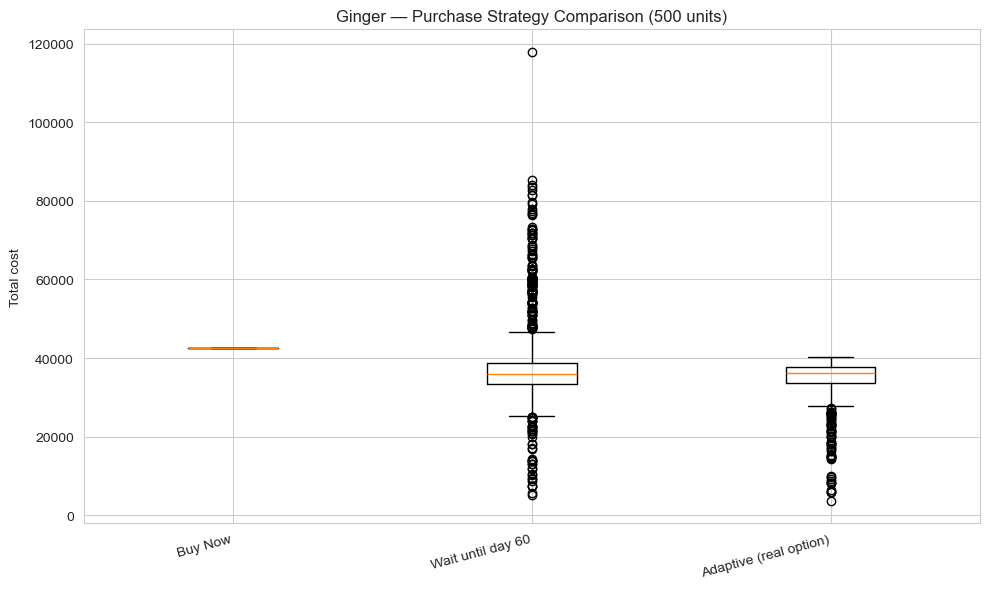

Value of waiting (fixed date) vs buying now: 4238
Additional value of adaptive/optional buying vs a fixed wait date: 3413
Total value of flexibility (adaptive vs buy-now): 7651


In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
data_to_plot = [cost_buy_now, cost_wait_fixed, cost_adaptive]
labels = strategy_comparison["strategy"].tolist()
ax.boxplot(data_to_plot, tick_labels=labels)
ax.set_ylabel("Total cost")
ax.set_title(f"{DEMO_COMMODITY} — Purchase Strategy Comparison ({QUANTITY_TO_BUY} units)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/purchase_strategy_comparison_{DEMO_COMMODITY.replace(' ', '_')}.png", dpi=150)
plt.show()

value_of_waiting = cost_buy_now.mean() - cost_wait_fixed.mean()
value_of_optionality = cost_wait_fixed.mean() - cost_adaptive.mean()
print(f"Value of waiting (fixed date) vs buying now: {value_of_waiting:.0f}")
print(f"Additional value of adaptive/optional buying vs a fixed wait date: {value_of_optionality:.0f}")
print(f"Total value of flexibility (adaptive vs buy-now): {cost_buy_now.mean() - cost_adaptive.mean():.0f}")

### Reading this for a business audience

- If `value_of_waiting` is negative, prices are expected to rise over the horizon (waiting costs more on average) — buying now may be preferable even before considering risk.
- The **adaptive strategy's real value** shows up mainly in `std_cost`/`p90_cost` being tighter than the fixed-wait strategy, not just in the mean — it avoids the worst outcomes by not being locked into one arbitrary date.
- `THRESHOLD_PRICE` is the key lever — set it too aggressively (very low) and the adaptive strategy will almost always end up forced to buy at the deadline anyway, which erases its advantage. Try a few threshold values and see how the comparison shifts.

## 4. Price-Guarantee / Insurance Contract Pricing

**Business question:** *"What would it cost to offer farmers a guaranteed minimum price for this commodity — and what premium would make that fair?"*

This treats a floor-price guarantee like an insurance contract: if the realized price falls below a floor `F`, the guarantor pays the farmer the difference; otherwise nothing is paid. Using the simulated price distribution, the **fair premium** is the expected payout — what an insurer would need to charge, on average, to break even before adding any margin.

In [21]:
GUARANTEE_HORIZON_DAYS = 90
GUARANTEE_QUANTITY = 500        # units covered by the guarantee
LOADING_FACTOR = 0.20           # insurer's margin/risk buffer on top of the fair (breakeven) premium

guarantee_paths = baseline_paths.iloc[:, :GUARANTEE_HORIZON_DAYS]
period_avg_price = guarantee_paths.mean(axis=1)   # average realized price over the guarantee period, per simulation

def price_guarantee(floor_price, realized_prices, quantity, loading=LOADING_FACTOR):
    payout = np.clip(floor_price - realized_prices, 0, None) * quantity
    fair_premium = payout.mean()
    priced_premium = fair_premium * (1 + loading)
    var95, cvar95 = var_cvar(payout, 0.95)
    return {
        "floor_price": floor_price, "fair_premium": fair_premium, "priced_premium": priced_premium,
        "payout_var95": var95, "payout_cvar95": cvar95,
        "probability_of_any_payout": (payout > 0).mean(),
    }

current_avg = demo_hist.iloc[-30:].mean()
FLOOR_PRICE = current_avg * 0.90   # example: guarantee 90% of the recent average price

result = price_guarantee(FLOOR_PRICE, period_avg_price, GUARANTEE_QUANTITY)
for k, v in result.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

floor_price: 73.05
fair_premium: 711.78
priced_premium: 854.14
payout_var95: 3308.92
payout_cvar95: 4615.03
probability_of_any_payout: 0.38


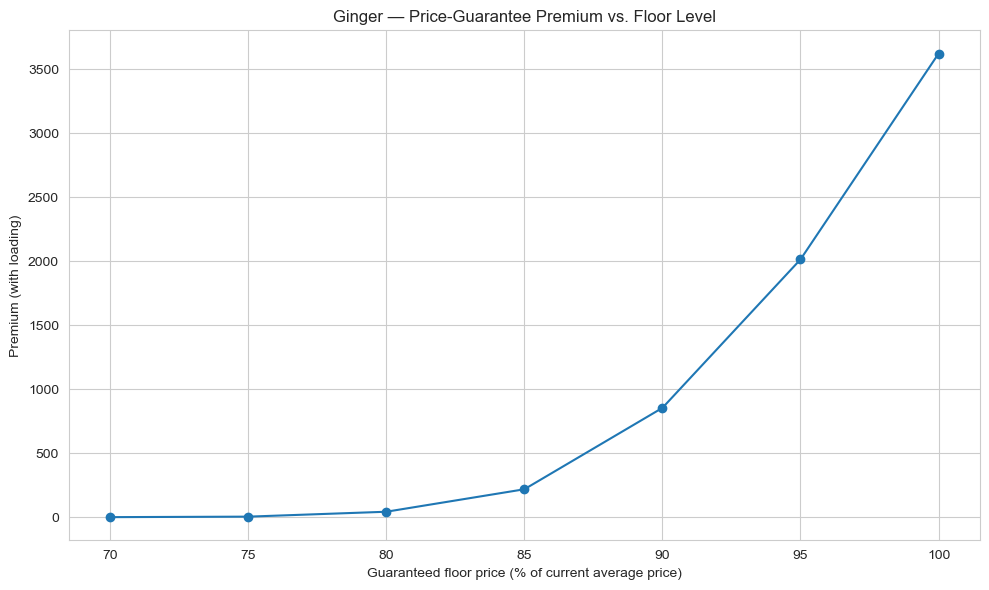

,floor_pct_of_current,fair_premium,priced_premium,probability_of_any_payout
0,0.70,0.40,0.48,0.00
1,0.75,3.61,4.33,0.00
2,0.80,35.53,42.64,0.03
3,0.85,181.88,218.25,0.15
4,0.90,711.78,854.14,0.38
5,0.95,1678.47,2014.16,0.57
6,1.00,3018.65,3622.38,0.73


In [22]:
# sweep the floor price to show the premium/floor trade-off -- higher guarantee, higher cost
floor_pcts = np.arange(0.70, 1.01, 0.05)
sweep = pd.DataFrame([price_guarantee(current_avg * p, period_avg_price, GUARANTEE_QUANTITY) for p in floor_pcts])
sweep["floor_pct_of_current"] = floor_pcts

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sweep["floor_pct_of_current"] * 100, sweep["priced_premium"], marker="o", color="tab:blue")
ax.set_xlabel("Guaranteed floor price (% of current average price)")
ax.set_ylabel("Premium (with loading)")
ax.set_title(f"{DEMO_COMMODITY} — Price-Guarantee Premium vs. Floor Level")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/insurance_premium_curve_{DEMO_COMMODITY.replace(' ', '_')}.png", dpi=150)
plt.show()
sweep[["floor_pct_of_current", "fair_premium", "priced_premium", "probability_of_any_payout"]].round(2)

### Reading this for a business audience

- `fair_premium` is the actuarially breakeven price — an insurer charging exactly this over many contracts neither profits nor loses on average.
- `priced_premium` adds `LOADING_FACTOR` as margin/reserve buffer — the number you'd actually charge.
- `payout_cvar95` is the average payout in the worst 5% of outcomes — the capital reserve an insurer/cooperative would need on hand to safely cover this contract at scale, not just the expected cost.
- The sweep curve is the key negotiating tool: it shows a farmer or policymaker exactly what a *stronger* guarantee (higher floor) actually costs, so the floor level becomes a concrete trade-off rather than an abstract ask.

## 5. Staggered Order Timing

**Business question:** *"Is it better to place one large order now, or split the same total quantity across several future weeks — and how many installments actually make a meaningful difference?"*

This mirrors the portfolio-diversification idea from `business_simulations.ipynb`, but diversifies across **time** instead of across commodities: buying a bit at several different points reduces exposure to any single bad-timing outcome, up to a point of diminishing returns.

In [23]:
TOTAL_QUANTITY = 1000
ORDER_HORIZON_DAYS = 90

def staggered_cost(paths, schedule, total_quantity):
    """schedule: list of day-offsets (within paths' columns) at which an equal fraction is purchased."""
    fraction = 1 / len(schedule)
    cost = np.zeros(paths.shape[0])
    for day in schedule:
        cost += paths.iloc[:, day].values * total_quantity * fraction
    return cost

order_paths = baseline_paths.iloc[:, :ORDER_HORIZON_DAYS]

strategies = {
    "1 order (day 0)": [0],
    "2 orders": np.linspace(0, ORDER_HORIZON_DAYS - 1, 2).astype(int).tolist(),
    "3 orders": np.linspace(0, ORDER_HORIZON_DAYS - 1, 3).astype(int).tolist(),
    "4 orders": np.linspace(0, ORDER_HORIZON_DAYS - 1, 4).astype(int).tolist(),
    "6 orders": np.linspace(0, ORDER_HORIZON_DAYS - 1, 6).astype(int).tolist(),
}

staggered_results = []
for name, schedule in strategies.items():
    cost = staggered_cost(order_paths, schedule, TOTAL_QUANTITY)
    staggered_results.append({
        "strategy": name, "n_installments": len(schedule),
        "mean_cost": cost.mean(), "std_cost": cost.std(), "cv": cost.std() / cost.mean(),
    })

staggered_df = pd.DataFrame(staggered_results)
staggered_df

,strategy,n_installments,mean_cost,std_cost,cv
0,1 order (day 0),1,77336.844926,22394.510706,0.289571
1,2 orders,2,74114.894800,15616.897087,0.210712
2,3 orders,3,73174.895051,12768.649561,0.174495
3,4 orders,4,76227.176823,11446.511051,0.150163
4,6 orders,6,74811.939455,9442.822804,0.126221


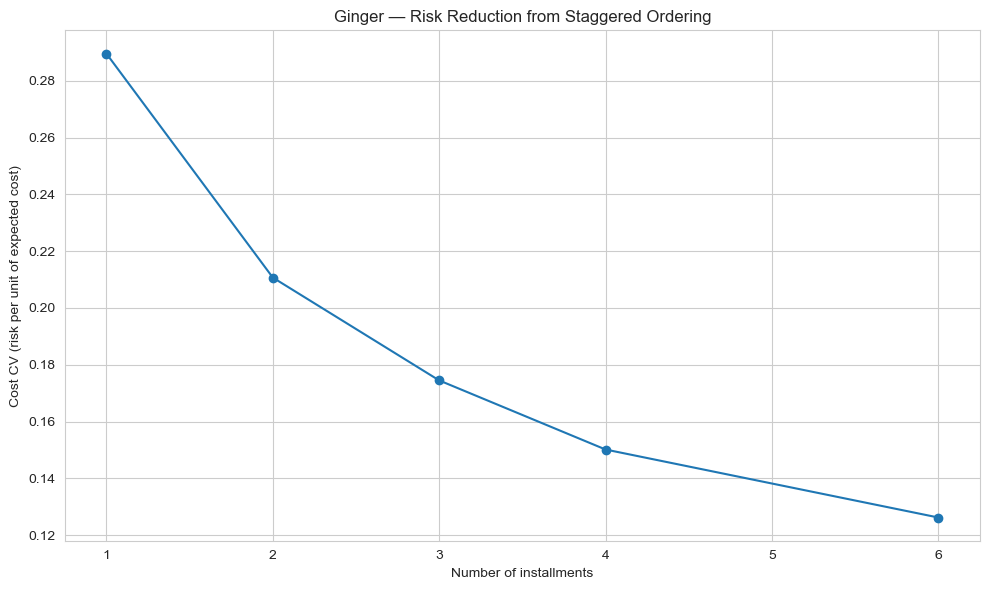

Risk (CV) with 1 order: 0.290
Risk (CV) with 6 orders: 0.126
Relative risk reduction: 56.4%

Mean cost across strategies ranges from 73175 to 77337 -- staggering is close to free in expectation, mainly a risk-reduction move rather than a cost-reduction one.


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(staggered_df["n_installments"], staggered_df["cv"], marker="o", color="tab:blue")
ax.set_xlabel("Number of installments"); ax.set_ylabel("Cost CV (risk per unit of expected cost)")
ax.set_title(f"{DEMO_COMMODITY} — Risk Reduction from Staggered Ordering")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/staggered_ordering_curve_{DEMO_COMMODITY.replace(' ', '_')}.png", dpi=150)
plt.show()

reduction = (staggered_df['cv'].iloc[0] - staggered_df['cv'].iloc[-1]) / staggered_df['cv'].iloc[0]
print(f"Risk (CV) with 1 order: {staggered_df['cv'].iloc[0]:.3f}")
print(f"Risk (CV) with {staggered_df['n_installments'].iloc[-1]} orders: {staggered_df['cv'].iloc[-1]:.3f}")
print(f"Relative risk reduction: {reduction:.1%}")
print(f"\nMean cost across strategies ranges from {staggered_df['mean_cost'].min():.0f} to "
      f"{staggered_df['mean_cost'].max():.0f} -- staggering is close to free in expectation, "
      f"mainly a risk-reduction move rather than a cost-reduction one.")

### Reading this for a business audience

- Like the cluster-based diversification curve, expect diminishing returns — the jump from 1 to 2 or 3 installments usually captures most of the benefit, with 4+ adding progressively less.
- Mean cost stays roughly flat across strategies (same total quantity, same average price exposure) — this is a **risk** story, not a cost-savings story, which is an important distinction to make clearly in a report.
- This section and Section 3 (buy-now vs. wait-and-see) answer related but distinct questions: Section 3 is about *whether and when* to make one decisive purchase, this section is about *splitting* a purchase across time regardless of direction.

## 6. Summary

| Section | Answers | Key output |
|---|---|---|
| 2. Shock stress-testing | Impact of a specific engineered scenario, not just ordinary noise | Extra expected cost & CVaR vs. baseline |
| 3. Buy-now vs. wait-and-see | Value of flexibility in a purchase decision | Cost comparison across 3 strategies |
| 4. Price-guarantee pricing | Fair premium for a floor-price contract | Premium vs. floor-level curve |
| 5. Staggered ordering | Risk reduction from splitting a purchase over time | CV vs. number of installments |

All four reuse the same STL + bootstrap Monte Carlo engine as `business_simulations.ipynb`, so results stay consistent with the rest of the project. Same standing caveats apply: trend extrapolation assumes recent drift continues, seasonal extrapolation assumes historical patterns repeat, and none of this anticipates a genuinely unprecedented shock — which is exactly why Section 2 exists, to let you deliberately model one instead of hoping the bootstrap happens to include something similar.